In [ ]:
# Import Libraries
# Load Data from yfinance
# Inspect Dataset
# Prepare Data
# Create Features and Target
# Train-Test Split
# Train Linear Regression Model
# Make Predictions
# Evaluate Model
# Plot Actual vs Predicted Prices
# Conclusion

In [51]:
# Import required libraries
import pandas as pd
import yfinance as yf

# Download historical stock data for Apple
apple_data = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

# Display the first few rows of the dataset
apple_data 

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200
...,...,...,...,...,...
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100


In [39]:
# we have multiindex columns 
apple_data.columns
apple_data["Next_Close"] = apple_data["Close"].shift(-1)
apple_data 

Price,Close,High,Low,Open,Volume,Next_Close
Date,,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400,71.630646
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,72.201424
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,71.861847
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,73.017822
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,74.568787
...,...,...,...,...,...,...
2024-12-19,248.204208,250.400185,245.521352,245.928753,60882300,252.874390
2024-12-20,252.874390,253.381146,244.130253,246.465325,147495300,253.649429
2024-12-23,253.649429,254.027007,251.840976,253.152604,40858800,256.560852


In [41]:

apple_data.dtypes
apple_data.shape
apple_data.isnull().sum()
apple_data.dropna(subset=["Next_Close"], inplace=True)
apple_data.isnull().sum()

Price
Close         0
High          0
Low           0
Open          0
Volume        0
Next_Close    0
dtype: int64

In [42]:
#Recomemnde libraries for stock price prediction 
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [ ]:
# prepare the data for modeling
X = apple_data[['Open', 'High', 'Low', 'Volume']]
y = apple_data['Next_Close']

In [45]:
# split the data into training and testing sets

# Split data without shuffling
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)
print(X_train.shape)
print(X_test.shape)

(1003, 4)
(251, 4)


In [46]:
# in this step we are going to train the model using linear regression
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
# in this step we will make predictions 
# Predict closing prices
y_pred = model.predict(X_test)
print(y_pred[:5])

[190.0671282  191.73363744 190.29329948 183.18929233 183.02503446]


In [49]:
# now we will evaluate the model
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Absolute Error: 2.3244890198997714
R2 Score: 0.9847729860295863


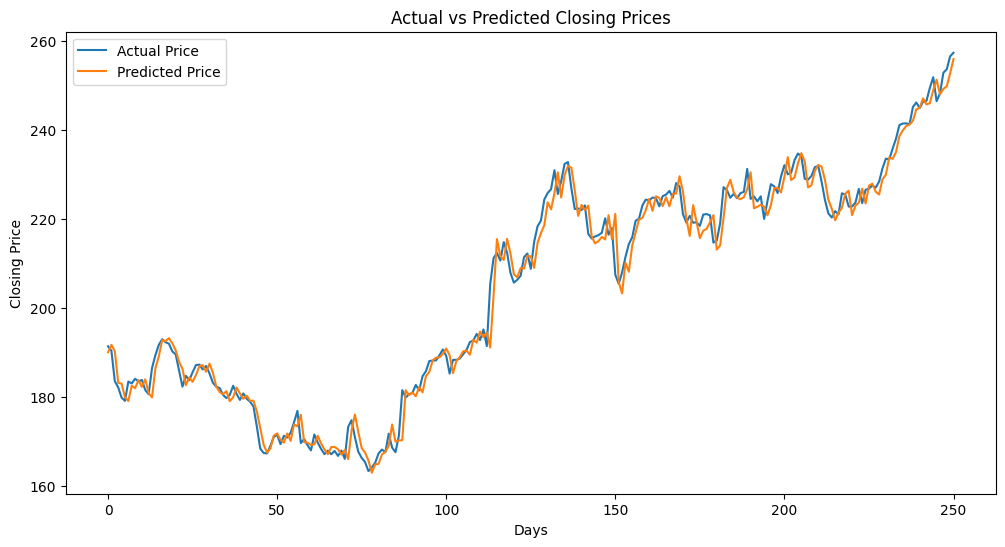

In [50]:
# Plot Actual vs Predicted Prices


plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Days')
plt.ylabel('Closing Price')
plt.legend()

plt.show()

In [ ]:
# Conclusion:

# - Historical Apple stock data was collected using yfinance.
# - Open, High, Low, and Volume were used as input features.
# - A Linear Regression model was trained to predict the next day's closing price.
# - The model's performance was evaluated using MAE and R² score.
# - Actual and predicted prices were compared visually using a line chart.